In [2]:
import pandas as pd
import numpy as np

# PREPROCESAMIENTO Y EDA

In [8]:
tl = pd.read_csv("C:/Hackathon CDMX/Data/STE/afluencia_desglosada_tl_04_2026.csv")

print(tl.shape)
tl.head()


(3162, 5)


,fecha,mes,anio,tipo_pago,afluencia
0,2022-01-01,Enero,2022,Prepago,14251.0
1,2022-01-01,Enero,2022,Gratuidad,1806.0
2,2022-01-02,Enero,2022,Prepago,21875.0
3,2022-01-02,Enero,2022,Gratuidad,2259.0
4,2022-01-03,Enero,2022,Prepago,49290.0


> se visualiza que no es necesario saber el tipo de pago de las personas para este reto, solo la afluencia del dia

In [9]:
# Crear columna 'dia' extrayendo el día de la fecha
tl['dia'] = pd.to_datetime(tl['fecha'], format='%Y-%m-%d').dt.day

# Agrupar por fecha, servicio, dia, mes y anio, sumando la afluencia
df_tl = tl.groupby(['fecha', 'dia', 'mes', 'anio'], as_index=False)['afluencia'].sum()

# Verificar resultado
print(df_tl.shape)
df_tl.head()


(1581, 5)


,fecha,dia,mes,anio,afluencia
0,2022-01-01,1,Enero,2022,16057.0
1,2022-01-02,2,Enero,2022,24134.0
2,2022-01-03,3,Enero,2022,55064.0
3,2022-01-04,4,Enero,2022,58005.0
4,2022-01-05,5,Enero,2022,57677.0


In [10]:
# Crear un DataFrame con el conteo y el porcentaje de nulos
missing_data = pd.DataFrame({
    'Nulos': df_tl.isnull().sum(),
    'Porcentaje': (df_tl.isnull().mean() * 100).round(2)
})

# Filtrar solo las columnas que tienen al menos un valor nulo
missing_data = missing_data[missing_data['Nulos'] > 0].sort_values(by='Nulos', ascending=False)

print(missing_data)

Empty DataFrame
Columns: [Nulos, Porcentaje]
Index: []


In [11]:
df_tl.info()

<class 'pandas.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      1581 non-null   str    
 1   dia        1581 non-null   int32  
 2   mes        1581 non-null   str    
 3   anio       1581 non-null   int64  
 4   afluencia  1581 non-null   float64
dtypes: float64(1), int32(1), int64(1), str(2)
memory usage: 81.3 KB


In [12]:
# Convertir fecha de string a formato fecha (datetime)
df_tl['fecha'] = pd.to_datetime(df_tl['fecha'], format='%Y-%m-%d')

# Convertir valores flotantes a enteros
df_tl['dia'] = df_tl['dia'].astype(int)
df_tl['anio'] = df_tl['anio'].astype(int)
df_tl['afluencia'] = df_tl['afluencia'].astype(int)

In [13]:
df_tl.info()
df_tl.head(1)

<class 'pandas.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fecha      1581 non-null   datetime64[us]
 1   dia        1581 non-null   int64         
 2   mes        1581 non-null   str           
 3   anio       1581 non-null   int64         
 4   afluencia  1581 non-null   int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 71.9 KB


,fecha,dia,mes,anio,afluencia
0,2022-01-01,1,Enero,2022,16057


In [14]:
df_tl.describe()

,fecha,dia,anio,afluencia
count,1581,1581.000000,1581.00000,1581.000000
mean,2024-03-01 00:00:00,15.714105,2023.69007,75950.183428
min,2022-01-01 00:00:00,1.000000,2022.00000,15091.000000
25%,2023-01-31 00:00:00,8.000000,2023.00000,56447.000000
50%,2024-03-01 00:00:00,16.000000,2024.00000,77874.000000
75%,2025-03-31 00:00:00,23.000000,2025.00000,90572.000000
max,2026-04-30 00:00:00,31.000000,2026.00000,139743.000000
std,NaN,8.795309,1.26244,26599.436362


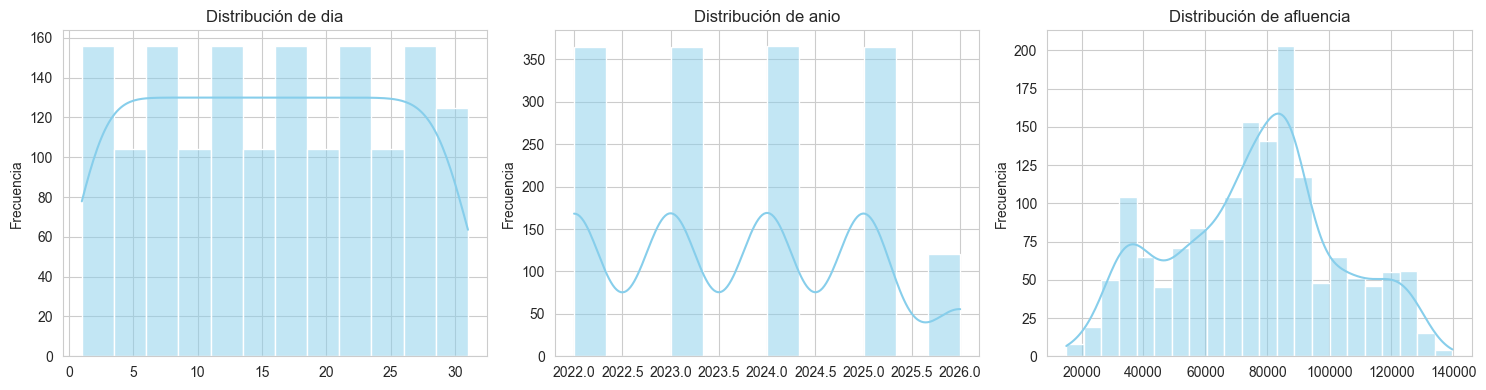

In [16]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar solo las columnas numéricas de tu DataFrame
df_numericas = df_tl.select_dtypes(include=["number"])
columnas = df_numericas.columns
num_columnas = len(columnas)

# 2. Configurar la cuadrícula de gráficos de forma dinámica
columnas_cuadricula = 3  # Número de gráficos por fila
filas_cuadricula = math.ceil(num_columnas / columnas_cuadricula)

# Definir el tamaño de la figura según la cantidad de filas
fig, axes = plt.subplots(
    filas_cuadricula,
    columnas_cuadricula,
    figsize=(5 * columnas_cuadricula, 4 * filas_cuadricula),
)
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# 3. Dibujar un histograma para cada variable numérica
for i, col in enumerate(columnas):
    sns.histplot(data=df_tl, x=col, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("")  # Quita etiquetas repetitivas para limpiar el diseño
    axes[i].set_ylabel("Frecuencia")

# 4. Ocultar los subgráficos vacíos (si el número de variables no es múltiplo de 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espacio para que no se encimen los textos
plt.tight_layout()
plt.show()


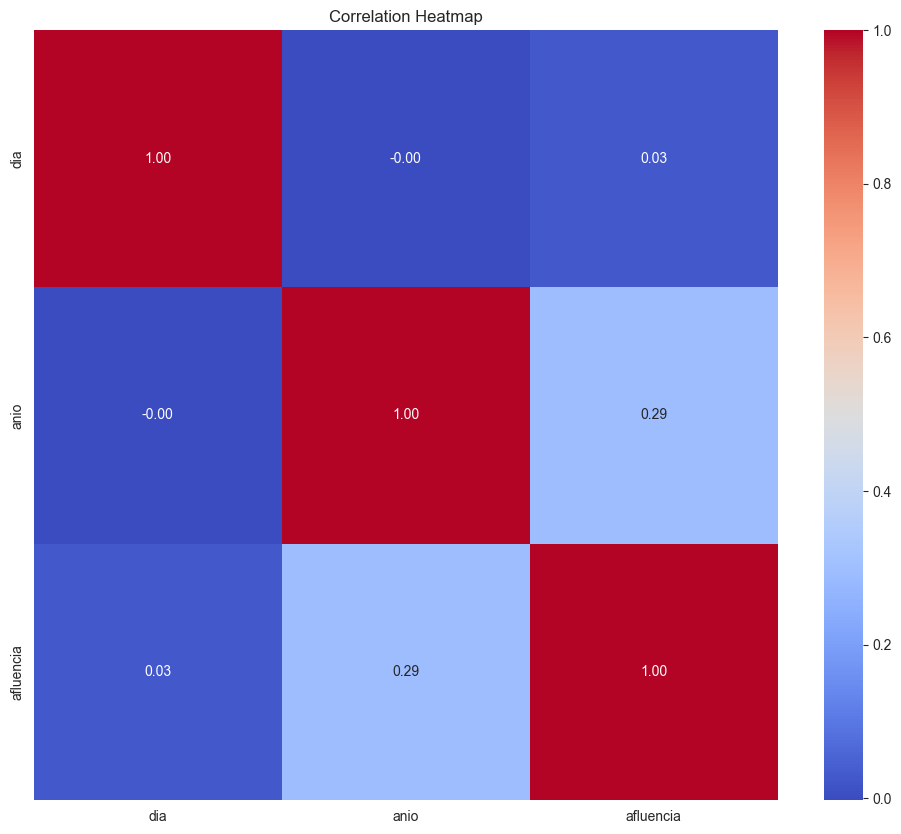

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

C = df_numericas.corr()

plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(C, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# CREACION NUEVO DF

In [19]:
#Guardar el archivo (Se agregó la 'r' para validar la ruta en Windows)
df_tl.to_csv(r'C:\Hackathon CDMX\clean_data\afluencia_electricos.csv', index=False)
